# Qualidade de Dados e Análise

1. **Qualidade** - completude, unicidade, acurácia, outliers e consistência.
2. **Análise** - uma consulta para cada pergunta de negócio, objetivo do MVP.

In [0]:
CATALOGO = "workspace"

# PARTE 1 - Qualidade de Dados

## 1.1 Completude - proporção de nulos por coluna

In [0]:
from pyspark.sql import functions as F

df = spark.table(f"{CATALOGO}.silver.producao_poco")
total = df.count()

exprs = [
    (F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)) / F.lit(total) * 100).alias(c)
    for c in df.columns
]
print(f"Total de linhas: {total:,}")
print("Percentual de nulos por coluna:")
display(df.select(*exprs))

Total de linhas: 607,046
Percentual de nulos por coluna:


periodo,campo,operadora,poco,bacia,localizacao,instalacao,ambiente,petroleo,gas,condensado,agua,classificacao,data_ref,ano,mes
0.0,0.0,0.06885804370673722,0.0,0.0,0.0,17.221264945325395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1.2 Unicidade - duplicatas de poço + mês

In [0]:
display(spark.sql(f"""
SELECT poco, ano, mes, COUNT(*) AS qtd
FROM {CATALOGO}.silver.producao_poco
GROUP BY poco, ano, mes
HAVING COUNT(*) > 1
ORDER BY qtd DESC
LIMIT 20
"""))

poco,ano,mes,qtd
7-SPH-16D-SPS,2025,12,4
7-BAZ-4-ESS,2025,12,4
7-SPH-20D-SPS,2025,11,4
7-BAZ-9HA-ESS,2026,1,4
7-JUB-63-ESS,2025,11,4
7-JUB-63-ESS,2025,12,4
7-JUB-58DPA-ESS,2025,11,4
7-SPH-1-SPS,2025,11,4
7-SPH-2D-SPS,2025,12,4
7-SPH-17-SPS,2025,11,4


## 1.3 Acurácia - volumes negativos

In [0]:
display(spark.sql(f"""
SELECT
  SUM(CASE WHEN petroleo   < 0 THEN 1 ELSE 0 END) AS petroleo_negativo,
  SUM(CASE WHEN gas        < 0 THEN 1 ELSE 0 END) AS gas_negativo,
  SUM(CASE WHEN condensado < 0 THEN 1 ELSE 0 END) AS condensado_negativo,
  SUM(CASE WHEN agua       < 0 THEN 1 ELSE 0 END) AS agua_negativo
FROM {CATALOGO}.silver.producao_poco
"""))

petroleo_negativo,gas_negativo,condensado_negativo,agua_negativo
0,0,0,0


## 1.4 Outliers - estatísticas dos volumes (min, max, média, desvio)

In [0]:
display(spark.table(f"{CATALOGO}.silver.producao_poco")
        .select("petroleo", "gas", "condensado", "agua").summary())

summary,petroleo,gas,condensado,agua
count,607046,607046,607046,607046
mean,381.13578329011847,17.63015348693081,0.8010771667243191,371.24096100691895
stddev,2759.0527511504565,131.01249280421646,18.21492148753411,1373.4066206804168
min,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0
50%,3.285167763,0.0032683870967741935,0.0,39.62243085025161
75%,12.987848958709677,0.07883333333333334,0.0,279.5338326233333
max,55063.77004302521,3339.387096774194,1458.2268248156665,56772.524576726435


## 1.5 Consistência

In [0]:
display(spark.sql(f"""
SELECT
  COUNT(*) AS total,
  SUM(CASE WHEN data_ref IS NULL THEN 1 ELSE 0 END) AS datas_invalidas,
  MIN(ano) AS ano_min, MAX(ano) AS ano_max
FROM {CATALOGO}.silver.producao_poco
"""))

total,datas_invalidas,ano_min,ano_max
607046,0,2021,2026


In [0]:
display(spark.sql(f"""
SELECT localizacao, classificacao, COUNT(*) AS qtd
FROM {CATALOGO}.silver.producao_poco
GROUP BY localizacao, classificacao
ORDER BY qtd DESC
"""))

localizacao,classificacao,qtd
TERRA,TERRA,540277
MAR,POS-SAL,42757
MAR,PRE-SAL,24012


# PARTE 2 - Análise

## P1 e P2 - Campos com maior produção acumulada de 2021 a agosto de 2026 + participação do pré-sal
Soma de produção de óleo por campo (top 10).

In [0]:
display(spark.sql(f"""
WITH producao_mensal AS (
    SELECT c.nome_campo, c.bacia, f.id_tempo,
           SUM(f.vol_petroleo) AS oleo_dia_no_mes
    FROM {CATALOGO}.gold.fato_producao f
    JOIN {CATALOGO}.gold.dim_campo c ON f.id_campo = c.id_campo
    GROUP BY c.nome_campo, c.bacia, f.id_tempo
)
SELECT nome_campo, bacia,
       FORMAT_NUMBER(SUM(oleo_dia_no_mes), '#,##0.00') AS soma_oleo_total
FROM producao_mensal
GROUP BY nome_campo, bacia
ORDER BY SUM(oleo_dia_no_mes) DESC
LIMIT 10
"""))

nome_campo,bacia,soma_oleo_total
TUPI,SANTOS,"56,102,521.53"
BÚZIOS,SANTOS,"45,202,284.69"
MERO,SANTOS,"19,227,964.20"
SAPINHOÁ,SANTOS,"10,314,697.04"
JUBARTE,CAMPOS,"9,277,677.85"
ATAPU,SANTOS,"7,732,927.56"
SÉPIA,SANTOS,"7,726,452.61"
RONCADOR,CAMPOS,"7,179,951.71"
ITAPU,SANTOS,"5,961,068.36"
MARLIM SUL,CAMPOS,"5,270,392.71"


In [0]:
# Participação da classificação (PRE-SAL / POS-SAL / TERRA) na produção total acumulada
display(spark.sql(f"""
WITH producao_mensal AS (
    SELECT c.classificacao_geologica, f.id_tempo,
           SUM(f.vol_petroleo) AS oleo_dia_no_mes
    FROM {CATALOGO}.gold.fato_producao f
    JOIN {CATALOGO}.gold.dim_campo c ON f.id_campo = c.id_campo
    GROUP BY c.classificacao_geologica, f.id_tempo
),
ranked AS (
    SELECT classificacao_geologica,
           SUM(oleo_dia_no_mes) AS soma_oleo,
           100.0 * AVG(oleo_dia_no_mes) / SUM(AVG(oleo_dia_no_mes)) OVER () AS pct
    FROM producao_mensal
    GROUP BY classificacao_geologica
)
SELECT classificacao_geologica,
       FORMAT_NUMBER(soma_oleo, '#,##0.00') AS soma_oleo_total,
       FORMAT_NUMBER(pct, '#,##0.00') AS pct_do_total
FROM ranked
ORDER BY pct DESC
"""))

classificacao_geologica,soma_oleo_total,pct_do_total
PRE-SAL,"180,770,866.56",78.13
POS-SAL,"45,227,295.08",19.55
TERRA,"5,368,791.07",2.32


## P3 - Produção mar (offshore) vs  produção terra (onshore)

In [0]:
display(spark.sql(f"""
WITH producao_mensal AS (
    SELECT c.ambiente AS localizacao, f.id_tempo,
           SUM(f.vol_petroleo) AS oleo_dia_no_mes
    FROM {CATALOGO}.gold.fato_producao f
    JOIN {CATALOGO}.gold.dim_campo c ON f.id_campo = c.id_campo
    GROUP BY c.ambiente, f.id_tempo
),
ranked AS (
    SELECT localizacao,
           SUM(oleo_dia_no_mes) AS soma_oleo,
           100.0 * AVG(oleo_dia_no_mes) / SUM(AVG(oleo_dia_no_mes)) OVER () AS pct
    FROM producao_mensal
    GROUP BY localizacao
)
SELECT localizacao,
       FORMAT_NUMBER(soma_oleo, '#,##0.00') AS soma_oleo_total,
       FORMAT_NUMBER(pct, '#,##0.00') AS pct_do_total
FROM ranked
ORDER BY pct DESC
"""))

localizacao,soma_oleo_total,pct_do_total
MAR,"225,998,161.64",97.68
TERRA,"5,368,791.07",2.32


## P4 - Produção por operadora (top 10)

In [0]:
display(spark.sql(f"""
WITH producao_mensal AS (
    SELECT o.nome_operadora, f.id_tempo,
           SUM(f.vol_petroleo) AS oleo_dia_no_mes
    FROM {CATALOGO}.gold.fato_producao f
    JOIN {CATALOGO}.gold.dim_operadora o ON f.id_operadora = o.id_operadora
    GROUP BY o.nome_operadora, f.id_tempo
),
ranked AS (
    SELECT nome_operadora,
           SUM(oleo_dia_no_mes) AS soma_oleo,
           100.0 * AVG(oleo_dia_no_mes) / SUM(AVG(oleo_dia_no_mes)) OVER () AS pct
    FROM producao_mensal
    GROUP BY nome_operadora
)
SELECT nome_operadora,
       FORMAT_NUMBER(soma_oleo, '#,##0.00') AS soma_oleo_total,
       FORMAT_NUMBER(pct, '#,##0.00') AS pct_do_total
FROM ranked
ORDER BY soma_oleo DESC
LIMIT 10
"""))

nome_operadora,soma_oleo_total,pct_do_total
PETROBRAS,"206,125,935.19",87.75
PRIO FORTE S.A,"4,138,276.81",1.76
PRIO TIGRIS,"4,132,305.43",1.76
TOTALENERGIES EP,"3,288,821.87",1.40
SHELL BRASIL,"1,815,704.95",0.77
3R POTIGUAR,"1,560,719.64",0.66
TRIDENT ENERGY,"1,486,521.08",0.63
KAROON BRASIL,"1,252,652.13",0.53
BRAVA ENERGIA S.A.,"1,087,076.79",0.46
PRIO BRAVO,"1,006,867.66",0.43


## P5 - Razão água/óleo por bacia
Quanto maior a razão, mais "maduro" tende a ser o campo (produz mais água por óleo).

In [0]:
display(spark.sql(f"""
WITH ranked AS (
    SELECT c.bacia,
           SUM(f.vol_agua) / NULLIF(SUM(f.vol_petroleo), 0) AS razao
    FROM {CATALOGO}.gold.fato_producao f
    JOIN {CATALOGO}.gold.dim_campo c ON f.id_campo = c.id_campo
    GROUP BY c.bacia
    HAVING SUM(f.vol_petroleo) > 0
)
SELECT bacia,
       FORMAT_NUMBER(razao, '#,##0.000') AS razao_agua_oleo
FROM ranked
ORDER BY razao DESC
"""))

bacia,razao_agua_oleo
CAMAMU,"5,651.199"
POTIGUAR,30.394
SERGIPE,22.154
RECÔNCAVO,21.219
ESPÍRITO SANTO,6.015
ALAGOAS,3.937
SOLIMÕES,2.393
CAMPOS,1.846
PARANÁ,0.710
BARREIRINHAS,0.098


## P6 - Evolução da produção média diária por ano
A média do ano de 2026 é parcial (dados disponíveis somente até agosto).

In [0]:
display(spark.sql(f"""
WITH producao_mensal AS (
    SELECT t.ano, f.id_tempo,
           SUM(f.vol_petroleo) AS oleo_dia_no_mes,
           SUM(f.vol_gas)      AS gas_dia_no_mes
    FROM {CATALOGO}.gold.fato_producao f
    JOIN {CATALOGO}.gold.dim_tempo t ON f.id_tempo = t.id_tempo
    GROUP BY t.ano, f.id_tempo
)
SELECT ano,
       FORMAT_NUMBER(SUM(oleo_dia_no_mes) / CASE WHEN ano = YEAR(CURRENT_DATE) THEN 8 ELSE 12 END, '#,##0.00') AS media_oleo_anual,
       FORMAT_NUMBER(SUM(gas_dia_no_mes) / CASE WHEN ano = YEAR(CURRENT_DATE) THEN 8 ELSE 12 END, '#,##0.00') AS media_gas_anual
FROM producao_mensal
GROUP BY ano
ORDER BY ano
"""))

ano,media_oleo_anual,media_gas_anual
2021,"2,896,726.25","133,747.36"
2022,"3,012,983.11","137,878.10"
2023,"3,394,047.35","149,809.29"
2024,"3,349,702.07","153,116.65"
2025,"3,758,509.27","178,993.73"
2026,"4,302,917.01","207,471.56"


### Gráfico de produção anual de óleo

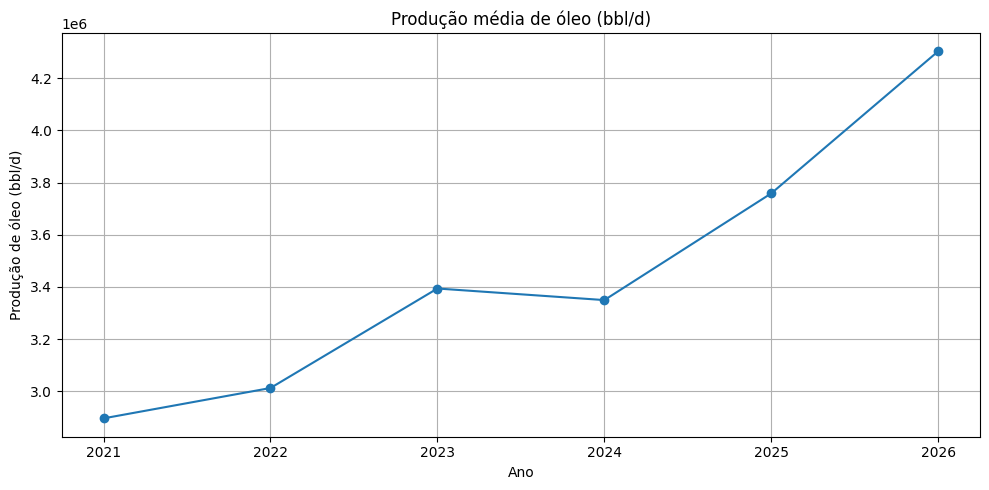

In [0]:
import matplotlib.pyplot as plt

pdf = spark.sql(f"""
WITH producao_mensal AS (
    SELECT t.ano, f.id_tempo, SUM(f.vol_petroleo) AS oleo_dia_no_mes
    FROM {CATALOGO}.gold.fato_producao f
    JOIN {CATALOGO}.gold.dim_tempo t ON f.id_tempo = t.id_tempo
    GROUP BY t.ano, f.id_tempo
)
SELECT ano,
       SUM(oleo_dia_no_mes) / CASE WHEN ano = YEAR(CURRENT_DATE) THEN 8 ELSE 12 END AS media_oleo_dia
FROM producao_mensal
GROUP BY ano ORDER BY ano
""").toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf["ano"], pdf["media_oleo_dia"], marker="o")
plt.title("Produção média de óleo (bbl/d)")
plt.xlabel("Ano"); plt.ylabel("Produção de óleo (bbl/d)")
plt.grid(True); plt.tight_layout()
plt.show()